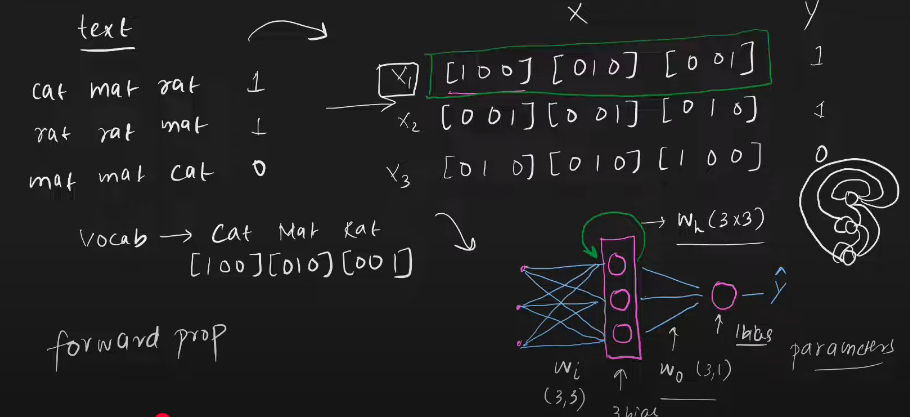

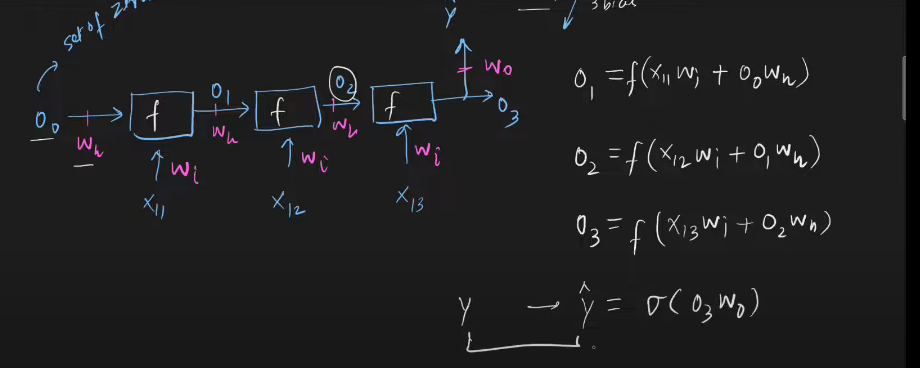

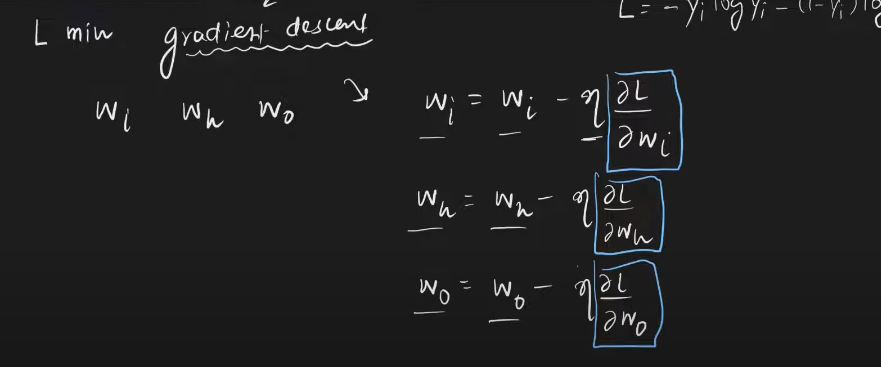

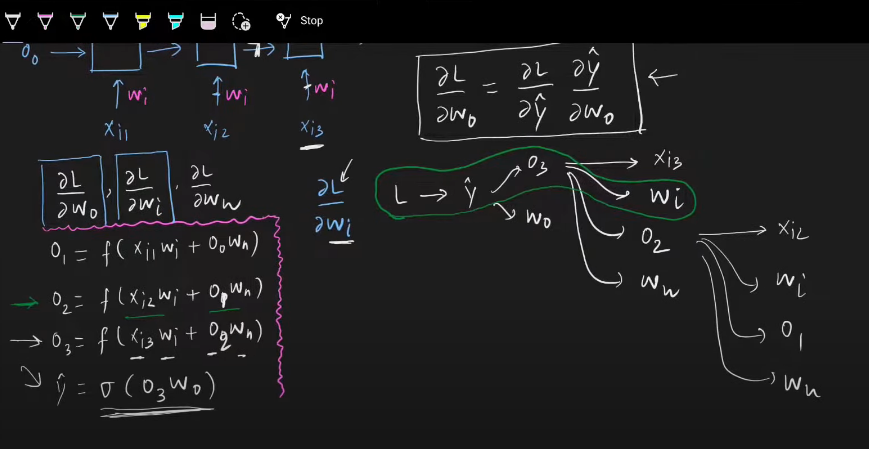

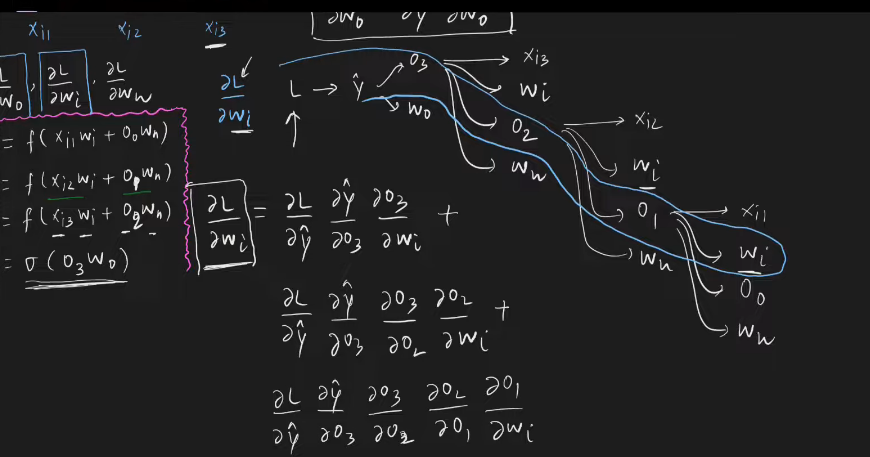

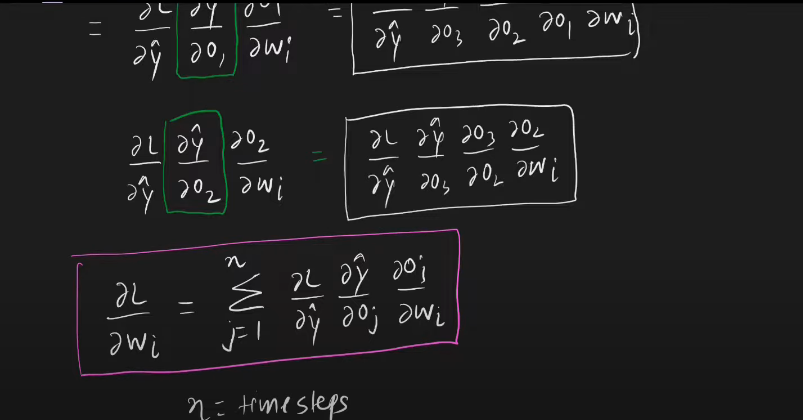

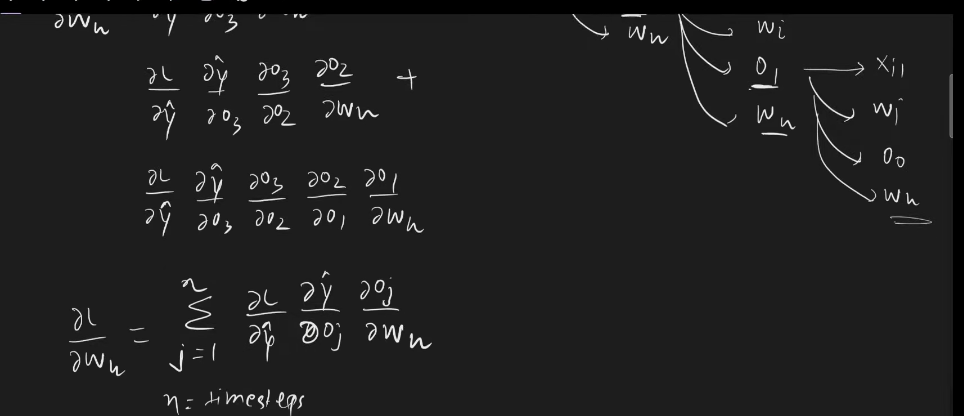


---

## 🎯 Goal: Understand Backpropagation in RNNs

We’ll build:
- A **3-timestep RNN**
- Input: 3 words (each one-hot encoded)
- Output: 1 label (0 or 1)

---

### 🔹 Step 1: Setup & Vocabulary

#### Vocabulary: `["cat", "mat", "rat"]`
Each word → one-hot vector:

| Word | Vector |
|------|--------|
| cat  | `[1, 0, 0]` |
| mat  | `[0, 1, 0]` |
| rat  | `[0, 0, 1]` |

Let’s say our training example is:
```
Input sequence: ["cat", "mat", "rat"]
Label: y = 1
```

We want to predict whether the sequence has "cat" (yes → 1).

---

### 🔹 Step 2: RNN Architecture

Our RNN has:
- Input weight matrix: $ W_i \in \mathbb{R}^{3 \times 3} $
- Hidden weight matrix: $ W_h \in \mathbb{R}^{3 \times 3} $
- Output weight: $ W_o \in \mathbb{R}^{3 \times 1} $
- Bias: $ b \in \mathbb{R}^3 $, $ b_o \in \mathbb{R}^1 $
- Activation function: $ f(\cdot) = \tanh $

> We’ll use **sigmoid** for final output (classification)

---

### 🔹 Step 3: Forward Pass (Step-by-Step)

Let’s define:
- $ x_t $: input at time $ t $
- $ h_t $: hidden state at time $ t $
- $ o_t $: output of RNN at time $ t $
- $ \hat{y} $: final prediction

#### Initial State:
$$
h_0 = [0, 0, 0]
$$

#### Parameters (randomly initialized):
Let’s pick small values for simplicity:

- $ W_i = \begin{bmatrix} 0.1 & 0.2 & 0.3 \\ 0.4 & 0.5 & 0.6 \\ 0.7 & 0.8 & 0.9 \end{bmatrix} $
- $ W_h = \begin{bmatrix} 0.2 & 0.1 & 0.3 \\ 0.4 & 0.3 & 0.2 \\ 0.1 & 0.4 & 0.5 \end{bmatrix} $
- $ W_o = \begin{bmatrix} 0.5 \\ 0.6 \\ 0.7 \end{bmatrix} $
- $ b = [0.1, 0.2, 0.3]^T $
- $ b_o = 0.1 $

---

### 🔸 Time Step 1: $ t = 1 $

Input: $ x_1 = [1, 0, 0] $ (for "cat")

$$
z_1 = x_1 W_i + h_0 W_h + b
$$
$$
= [1,0,0] \cdot W_i + [0,0,0] \cdot W_h + [0.1, 0.2, 0.3]
= [0.1, 0.4, 0.7] + [0,0,0] + [0.1, 0.2, 0.3]
= [0.2, 0.6, 1.0]
$$

$$
h_1 = \tanh(z_1) = \tanh([0.2, 0.6, 1.0]) \approx [0.197, 0.537, 0.761]
$$

---

### 🔸 Time Step 2: $ t = 2 $

Input: $ x_2 = [0, 1, 0] $ (for "mat")

$$
z_2 = x_2 W_i + h_1 W_h + b
$$
$$
= [0,1,0] \cdot W_i + [0.197, 0.537, 0.761] \cdot W_h + [0.1, 0.2, 0.3]
$$

Compute:
- $ x_2 W_i = [0.2, 0.5, 0.8] $
- $ h_1 W_h = [0.197*0.2 + 0.537*0.4 + 0.761*0.1, ...] $
  - First element: $ 0.0394 + 0.2148 + 0.0761 = 0.3303 $
  - Second: $ 0.197*0.1 + 0.537*0.3 + 0.761*0.4 = 0.0197 + 0.1611 + 0.3044 = 0.4852 $
  - Third: $ 0.197*0.3 + 0.537*0.2 + 0.761*0.5 = 0.0591 + 0.1074 + 0.3805 = 0.547 $
- Add bias: $ + [0.1, 0.2, 0.3] $

So:
$$
z_2 = [0.2+0.3303+0.1, 0.5+0.4852+0.2, 0.8+0.547+0.3] = [0.6303, 1.1852, 1.647]
$$

$$
h_2 = \tanh(z_2) \approx [0.563, 0.844, 0.920]
$$

---

### 🔸 Time Step 3: $ t = 3 $

Input: $ x_3 = [0, 0, 1] $ (for "rat")

$$
z_3 = x_3 W_i + h_2 W_h + b
$$
- $ x_3 W_i = [0.3, 0.6, 0.9] $
- $ h_2 W_h = [0.563*0.2 + 0.844*0.4 + 0.920*0.1, ...] $
  - First: $ 0.1126 + 0.3376 + 0.092 = 0.5422 $
  - Second: $ 0.563*0.1 + 0.844*0.3 + 0.920*0.4 = 0.0563 + 0.2532 + 0.368 = 0.6775 $
  - Third: $ 0.563*0.3 + 0.844*0.2 + 0.920*0.5 = 0.1689 + 0.1688 + 0.460 = 0.800 $
- Add bias: $ + [0.1, 0.2, 0.3] $

$$
z_3 = [0.3+0.5422+0.1, 0.6+0.6775+0.2, 0.9+0.800+0.3] = [0.9422, 1.4775, 2.0]
$$

$$
h_3 = \tanh(z_3) \approx [0.731, 0.911, 0.964]
$$

---

### 🔸 Final Output: $ \hat{y} $

Now compute output:
$$
o_3 = h_3 W_o + b_o
= [0.731, 0.911, 0.964] \cdot \begin{bmatrix} 0.5 \\ 0.6 \\ 0.7 \end{bmatrix} + 0.1
= (0.731×0.5 + 0.911×0.6 + 0.964×0.7) + 0.1
= (0.3655 + 0.5466 + 0.6748) + 0.1 = 1.5869 + 0.1 = 1.6869
$$

$$
\hat{y} = \sigma(o_3) = \frac{1}{1 + e^{-1.6869}} \approx 0.846
$$

Target: $ y = 1 $

---

### 🔹 Step 4: Loss Function

Use **Binary Cross-Entropy**:

$$
L = -y \log(\hat{y}) - (1-y)\log(1-\hat{y})
$$

$$
L = -1 \cdot \log(0.846) - 0 \cdot \log(1-0.846) = -(-0.167) = 0.167
$$

We want to minimize $ L $ by updating weights.

---

### 🔹 Step 5: Backward Pass (Backpropagation Through Time)

We compute gradients of loss w.r.t. all parameters: $ W_i, W_h, W_o $

We use **chain rule** and **gradient descent**:

$$
W_i \leftarrow W_i - \eta \frac{\partial L}{\partial W_i}
$$
$$
W_h \leftarrow W_h - \eta \frac{\partial L}{\partial W_h}
$$
$$
W_o \leftarrow W_o - \eta \frac{\partial L}{\partial W_o}
$$

Let’s compute each gradient.

---

### 🔸 Gradient w.r.t. $ W_o $

$$
\frac{\partial L}{\partial W_o} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial o_3} \cdot \frac{\partial o_3}{\partial W_o}
$$

- $ \frac{\partial L}{\partial \hat{y}} = \frac{-(y - \hat{y})}{\hat{y}(1 - \hat{y})} = \frac{-(1 - 0.846)}{0.846 \cdot 0.154} \approx \frac{-0.154}{0.130} \approx -1.185 $
- $ \frac{\partial \hat{y}}{\partial o_3} = \sigma'(o_3) = \hat{y}(1 - \hat{y}) = 0.846 \cdot 0.154 \approx 0.130 $
- $ \frac{\partial o_3}{\partial W_o} = h_3 $

So:
$$
\frac{\partial L}{\partial W_o} = (-1.185) \cdot (0.130) \cdot h_3 \approx -0.154 \cdot h_3
$$

$$
\frac{\partial L}{\partial W_o} \approx [-0.113, -0.134, -0.142]
$$

---

### 🔸 Gradient w.r.t. $ W_h $

This is more complex — we need to backpropagate through time.

General formula:
$$
\frac{\partial L}{\partial W_h} = \sum_{t=1}^{T} \frac{\partial L}{\partial h_t} \cdot \frac{\partial h_t}{\partial W_h}
$$

But $ \frac{\partial h_t}{\partial W_h} $ depends on past states.

We use **backpropagation through time (BPTT)**:

At $ t=3 $:
- $ \frac{\partial L}{\partial h_3} = \frac{\partial L}{\partial o_3} \cdot \frac{\partial o_3}{\partial h_3} = (-1.185) \cdot (0.130) \cdot W_o = -0.154 \cdot W_o $

Then:
$$
\frac{\partial h_3}{\partial W_h} = \text{diag}( \text{d}h_3 / \text{d}z_3 ) \cdot h_2
$$
Where $ \text{diag}( \tanh' ) = 1 - \tanh^2 $

So:
$$
\frac{\partial L}{\partial W_h} \leftarrow \text{grad}_h \cdot h_2^T
$$

Repeat for $ t=2 $, $ t=1 $, summing up.

---

### 🔸 General Formula for BPTT

For each parameter:

$$
\frac{\partial L}{\partial W_h} = \sum_{t=1}^{T} \left( \frac{\partial L}{\partial h_t} \right) \cdot h_{t-1}^T
$$

And:
$$
\frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial h_{t+1}} \cdot \frac{\partial h_{t+1}}{\partial h_t} + \frac{\partial L}{\partial o_t} \cdot \frac{\partial o_t}{\partial h_t}
$$

This is **recursive** — we start from $ t=T $ and go backward.

---

### 🔹 Summary: General Formulas

| Parameter | Update Rule |
|---------|------------|
| $ W_i $ | $ \sum_{t=1}^{T} \frac{\partial L}{\partial h_t} \cdot x_t^T $ |
| $ W_h $ | $ \sum_{t=1}^{T} \frac{\partial L}{\partial h_t} \cdot h_{t-1}^T $ |
| $ W_o $ | $ \frac{\partial L}{\partial o_T} \cdot h_T^T $ |

And:
- $ \frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial h_{t+1}} \cdot (1 - h_t^2) \cdot W_h^T $ (for tanh)
- $ \frac{\partial L}{\partial o_t} = \sigma'(o_t) \cdot (y - \hat{y}) $

---

### ✅ Final Takeaway

- **Forward pass**: Compute hidden states step-by-step.
- **Loss**: Compare prediction to true label.
- **Backward pass**: Use chain rule and BPTT to compute gradients.
- **Update**: Adjust weights via gradient descent.

This is how RNNs learn from sequences — **one timestep at a time**, with gradients flowing backward.

---





---

### ❓Q1: Can you explain how backpropagation works in RNNs?

**✅ Candidate Answer:**

Yes.

In RNNs, backpropagation is called **Backpropagation Through Time (BPTT)** because the network is "unrolled" across time steps, and gradients are computed with respect to each timestep.

Here’s how it works:

1. **Forward Pass**:  
   We process the input sequence step-by-step:  
   At each time $ t $, compute:
   $$
   h_t = \tanh(W_i x_t + W_h h_{t-1} + b)
   $$
   Then final output:
   $$
   \hat{y} = \sigma(W_o h_T + b_o)
   $$

2. **Loss Calculation**:  
   Compute loss (e.g., cross-entropy) between $ \hat{y} $ and true label $ y $.

3. **Backward Pass (BPTT)**:  
   We apply the chain rule **backward through time**:
   - Start from the last timestep $ T $
   - Compute gradients of loss w.r.t. output weights $ W_o $
   - Then propagate error **into the hidden states**, and through time:  
     $$
     \frac{\partial L}{\partial h_t} = \frac{\partial L}{\partial h_{t+1}} \cdot \frac{\partial h_{t+1}}{\partial h_t} + \frac{\partial L}{\partial o_t} \text{ (if predicting at every step)}
     $$
   - This recursive dependency means we go from $ t=T $ down to $ t=1 $

4. **Weight Updates**:  
   Finally:
   $$
   \frac{\partial L}{\partial W_h} = \sum_{t=1}^T \frac{\partial L}{\partial h_t} \cdot h_{t-1}^T
   $$
   $$
   \frac{\partial L}{\partial W_i} = \sum_{t=1}^T \frac{\partial L}{\partial h_t} \cdot x_t^T
   $$
   Then update weights using gradient descent.

🧠 **Key Insight**:  
Unlike feedforward networks, RNN gradients depend on **past hidden states**, so we must backpropagate not just layer-by-layer, but **time-step-by-time-step**.

⚠️ **Challenge**: Vanishing/exploding gradients — which is why we use LSTMs or gradient clipping in practice.

---

### ❓Q2: Why is it called "Backpropagation Through Time"?

**✅ Candidate Answer:**

Because we **unroll the RNN across time steps** and treat it like a deep feedforward network with shared weights.

For example, an RNN with 3 timesteps becomes a 3-layer network:
```
x₁ → h₁ → x₂ → h₂ → x₃ → h₃ → ŷ
```

But the weights $ W_h $ and $ W_i $ are **shared across all steps**.

So during backpropagation, we compute gradients at each step and **sum them up** for the same weight matrix.

That’s why it’s "through time" — we’re going backward in time, accumulating gradients over timesteps.

---

### ❓Q3: What are the challenges with BPTT?

**✅ Candidate Answer:**

Two major issues:

1. **Vanishing Gradients**:  
   When gradients pass through many timesteps, repeated multiplication by $ \frac{\partial h_t}{\partial h_{t-1}} $ (which is less than 1 for tanh) causes gradients to shrink exponentially.  
   → The model can't learn long-range dependencies.

2. **Exploding Gradients**:  
   In some cases, gradients grow too large, causing unstable updates.

👉 Solutions:
- Use **LSTM/GRU** (gates help preserve gradients)
- Apply **gradient clipping** (e.g., clip norm > 5)
- Use **skip connections** or **ReLU-like activations**

These issues are a key reason why Transformers (with attention) have largely replaced RNNs for long sequences.

---

### ❓Q4: How do you compute gradients for shared weights in RNNs?

**✅ Candidate Answer:**

Since weights like $ W_h $ and $ W_i $ are **shared across timesteps**, the total gradient is the **sum of gradients at each timestep**.

For example:
$$
\frac{\partial L}{\partial W_h} = \sum_{t=1}^T \frac{\partial L}{\partial W_h^{(t)}}
$$
Where $ W_h^{(t)} $ is the use of $ W_h $ at time $ t $.

Each term is computed via chain rule:
$$
\frac{\partial L}{\partial W_h^{(t)}} = \frac{\partial L}{\partial h_t} \cdot \frac{\partial h_t}{\partial W_h}
$$

And $ \frac{\partial L}{\partial h_t} $ depends on both:
- Direct loss at $ t $ (if predicting per step)
- Future losses via $ h_{t+1}, h_{t+2}, \dots $

So we sum contributions from **all future timesteps** — that’s BPTT.

---

### ❓Q5: Can you give a simple example of BPTT?

**✅ Candidate Answer:**

Sure.

Imagine a 2-timestep RNN for sentiment analysis:

- $ x_1 $: "I" → $ h_1 $
- $ x_2 $: "love" → $ h_2 $ → $ \hat{y} = 0.7 $, true $ y = 1 $

**Forward pass**: Compute $ h_1, h_2, \hat{y} $

**Loss**: $ L = -y \log(\hat{y}) = -\log(0.7) \approx 0.357 $

**Backward pass**:
1. $ \frac{\partial L}{\partial \hat{y}} = \frac{-(y - \hat{y})}{\hat{y}(1-\hat{y})} $
2. $ \frac{\partial \hat{y}}{\partial h_2} = W_o $
3. So $ \frac{\partial L}{\partial h_2} = \text{scalar} \times W_o $

Now, this error flows back to $ h_1 $:
$$
\frac{\partial L}{\partial h_1} = \frac{\partial L}{\partial h_2} \cdot \frac{\partial h_2}{\partial h_1}
$$
Where $ \frac{\partial h_2}{\partial h_1} = (1 - h_2^2) \cdot W_h^T $ (derivative of tanh)

Then:
- $ \frac{\partial L}{\partial W_h} = \frac{\partial L}{\partial h_1} \cdot h_0^T + \frac{\partial L}{\partial h_2} \cdot h_1^T $
- $ \frac{\partial L}{\partial W_i} = \frac{\partial L}{\partial h_1} \cdot x_1^T + \frac{\partial L}{\partial h_2} \cdot x_2^T $

We sum gradients from both steps because weights are shared.

---

### ❓Q6: How is BPTT different from regular backpropagation?

**✅ Candidate Answer:**

| Regular Backprop | BPTT |
|------------------|------|
| Across layers | Across time steps |
| Fixed depth | Can be very long |
| No weight sharing | Weights shared across time |
| Gradients don’t accumulate over sequence | Gradients summed over timesteps |
| Stable for moderate depth | Prone to vanishing/exploding gradients |

So BPTT is **backpropagation + time unrolling + gradient summation**.

It’s more complex because of recurrence and long chains.

---

### ✅ Final Summary

> "Backpropagation in RNNs — called BPTT — works by unrolling the network across time, computing gradients at each step, and summing them for shared weights. It allows RNNs to learn from sequences, but suffers from vanishing/exploding gradients, which is why we use LSTMs or move to Transformers for long-range modeling."

---

